# SVC and RandomForest comparison

In [1]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics import ConfusionMatrixDisplay, RocCurveDisplay
import pickle
from sklearn.svm import SVC


import warnings
warnings.filterwarnings("ignore")

In [2]:
X_train_processed = pd.read_csv('../data/X_train.csv')
X_test_processed = pd.read_csv('../data/X_test.csv')
X_valid_processed = pd.read_csv('../data/X_valid.csv')
y_train = pd.read_csv('../data/y_train.csv')
y_test = pd.read_csv('../data/y_test.csv')
y_valid = pd.read_csv('../data/y_valid.csv')

In [3]:
X_train_val = pd.concat([X_train_processed, X_valid_processed], axis=0, ignore_index=True)
y_train_val = pd.concat([y_train, y_valid], axis=0, ignore_index=True)

## RandomForest (Best hyperparameters)

In [4]:
rf_model = RandomForestClassifier(
    random_state=40,
    n_estimators=300,
    max_depth=None,
    max_features="sqrt",
    min_samples_split=2,
    min_samples_leaf=1,
    n_jobs=-1
)

rf_model.fit(X_train_val, y_train_val)
print("Random Forest")
print(classification_report(y_test, rf_model.predict(X_test_processed)))
print(f"Accuracy score for x_test: {accuracy_score(y_test, rf_model.predict(X_test_processed)):.4f}")
print(f"Accuracy score for x_train: {accuracy_score(y_train_val, rf_model.predict(X_train_val)):.4f}")

Random Forest
              precision    recall  f1-score   support

           0       0.92      0.95      0.93      3651
           1       0.88      0.82      0.85      1791

    accuracy                           0.91      5442
   macro avg       0.90      0.89      0.89      5442
weighted avg       0.91      0.91      0.91      5442

Accuracy score for x_test: 0.9068
Accuracy score for x_train: 0.9940


Saving final RandomForest

In [5]:
with open("../models/random_forest_model_final.pkl", "wb") as f:
    pickle.dump(rf_model, f)

**Confusion Matrix:**
The confusion matrix shows how many predictions were correct and incorrect for each class, breaking results into true positives, true negatives, false positives, and false negatives, which helps identify the types of errors the model makes.

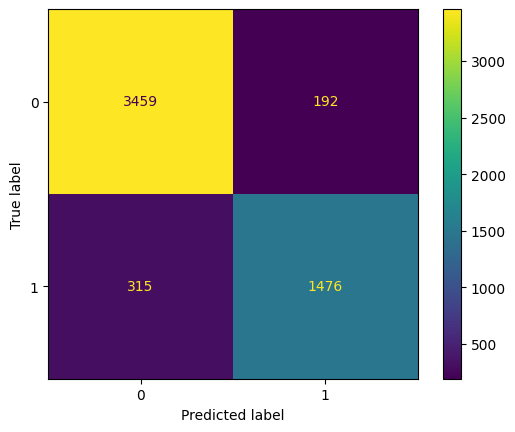

In [6]:
ConfusionMatrixDisplay.from_predictions(y_test, rf_model.predict(X_test_processed))

**ROC Curve:**
The ROC curve illustrates the trade-off between the true positive rate and the false positive rate across different decision thresholds, while the AUC summarizes how well the model can distinguish between the two classes.

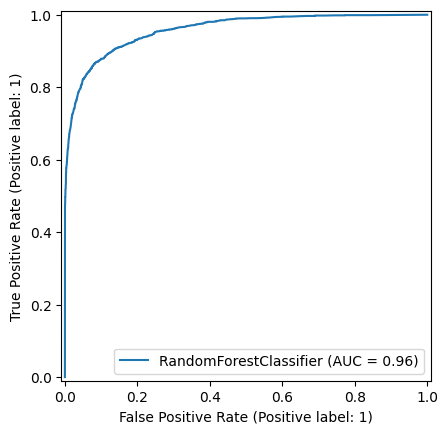

In [7]:
RocCurveDisplay.from_estimator(rf_model, X_test_processed, y_test)

In [14]:
importances

array([1.43698913e-02, 5.03309202e-03, 3.07938364e-02, 4.49785927e-02,
       6.23672458e-03, 2.84214716e-01, 1.90096752e-03, 2.97977548e-04,
       2.01844400e-03, 1.34654250e-01, 1.05854821e-01, 1.77181754e-02,
       1.40873924e-02, 1.56534465e-02, 3.58784161e-02, 4.57645811e-02,
       5.84704474e-02, 5.21904086e-02, 1.70052593e-02, 2.37721877e-02,
       8.54660154e-03, 9.32635434e-03, 4.98100914e-05, 6.25575747e-03,
       6.95634693e-03, 1.92968297e-03, 2.03920333e-05, 6.47859552e-03,
       1.53259074e-03, 1.46382100e-03, 3.21959916e-04, 4.74134064e-04,
       4.72976356e-04, 4.59046412e-03, 1.60709489e-02, 2.46159374e-02])

In [16]:
X_train_val.columns

Index(['num__no_of_adults', 'num__no_of_children', 'num__no_of_weekend_nights',
       'num__no_of_week_nights', 'num__required_car_parking_space',
       'num__lead_time', 'num__repeated_guest',
       'num__no_of_previous_cancellations',
       'num__no_of_previous_bookings_not_canceled', 'num__avg_price_per_room',
       'num__no_of_special_requests', 'num__no_of_people',
       'num__arrival_year_sin', 'num__arrival_year_cos',
       'num__arrival_month_sin', 'num__arrival_month_cos',
       'num__arrival_date_sin', 'num__arrival_date_cos',
       'num__arrival_weekday_sin', 'num__arrival_weekday_cos',
       'cat__type_of_meal_plan_Meal Plan 1',
       'cat__type_of_meal_plan_Meal Plan 2',
       'cat__type_of_meal_plan_Meal Plan 3',
       'cat__type_of_meal_plan_Not Selected',
       'cat__room_type_reserved_Room_Type 1',
       'cat__room_type_reserved_Room_Type 2',
       'cat__room_type_reserved_Room_Type 3',
       'cat__room_type_reserved_Room_Type 4',
       'cat__room_typ

**Feature importance**

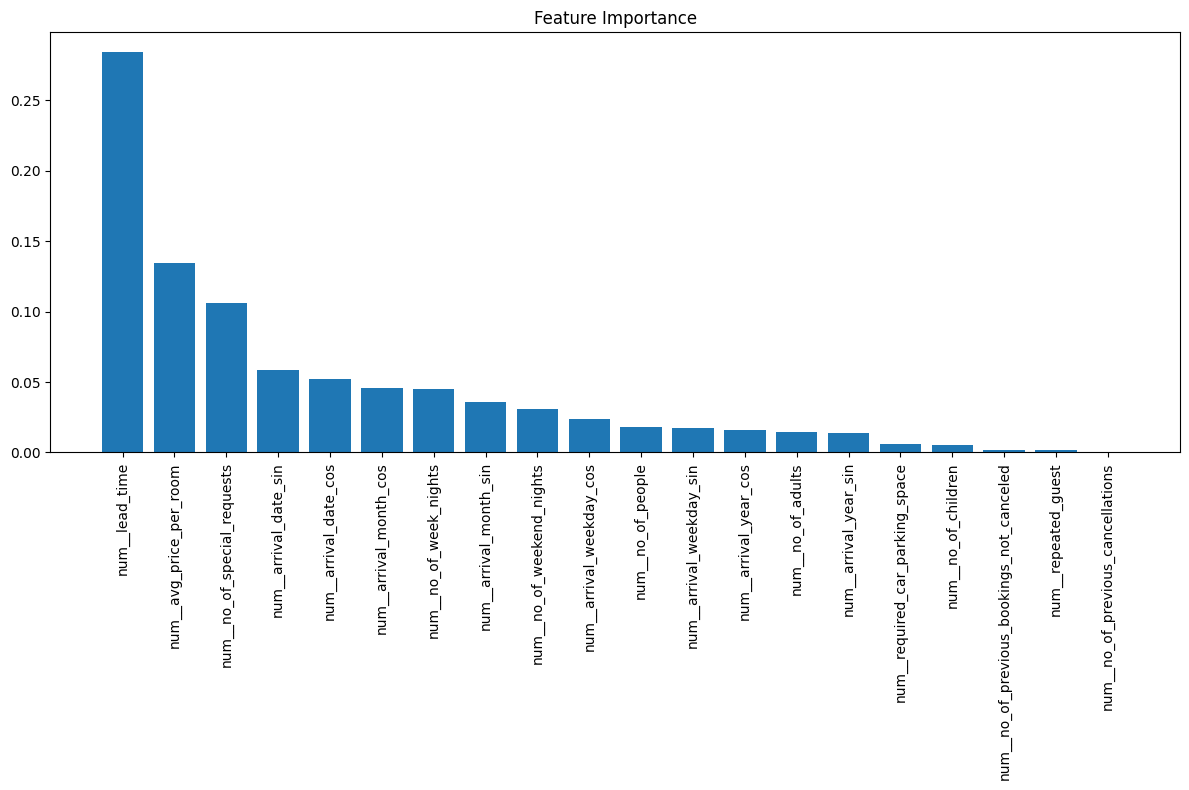

In [17]:
import matplotlib.pyplot as plt
import numpy as np


feature_mask = [
    "num__no_of_adults",
    "num__no_of_children",
    "num__no_of_weekend_nights",
    "num__no_of_week_nights",
    "num__required_car_parking_space",
    "num__lead_time",
    "num__repeated_guest",
    "num__no_of_previous_cancellations",
    "num__no_of_previous_bookings_not_canceled",
    "num__avg_price_per_room",
    "num__no_of_special_requests",
    "num__no_of_people",
    "num__arrival_year_sin",
    "num__arrival_year_cos",
    "num__arrival_month_sin",
    "num__arrival_month_cos",
    "num__arrival_date_sin",
    "num__arrival_date_cos",
    "num__arrival_weekday_sin",
    "num__arrival_weekday_cos",
]

# Feature importance from trained model
importances = rf_model.feature_importances_

# We only match the filtered features
importances_filtered = [
    importances[i] for i, col in enumerate(X_train_val.columns) if col in feature_mask
]

indices = np.argsort(importances_filtered)[::-1]

plt.figure(figsize=(12, 8))
plt.title("Feature Importance")
plt.bar(
    range(len(importances_filtered)),
    np.array(importances_filtered)[indices],
    align="center",
)
plt.xticks(
    range(len(importances_filtered)), [feature_mask[i] for i in indices], rotation=90
)
plt.tight_layout()
plt.show()

## SVC (Best hyperparameters)

In [10]:
svc_model = SVC(C=10, gamma=0.1, kernel='rbf')
svc_model.fit(X_train_val, y_train_val)

print("SVC")
print(f"Accuracy score for x_train_val: {accuracy_score(y_train_val, svc_model.predict(X_train_val)):.4f}")
acc_valid = accuracy_score(y_test, svc_model.predict(X_test_processed))
print(f"Accuracy score for x_test: {acc_valid:.4f}")
print(classification_report(y_test, svc_model.predict(X_test_processed)))

SVC
Accuracy score for x_train_val: 0.9274
Accuracy score for x_test: 0.8741
              precision    recall  f1-score   support

           0       0.89      0.92      0.91      3651
           1       0.83      0.78      0.80      1791

    accuracy                           0.87      5442
   macro avg       0.86      0.85      0.86      5442
weighted avg       0.87      0.87      0.87      5442



In [11]:
with open("../models/svc_final.pkl", "wb") as f:
    pickle.dump(rf_model, f)

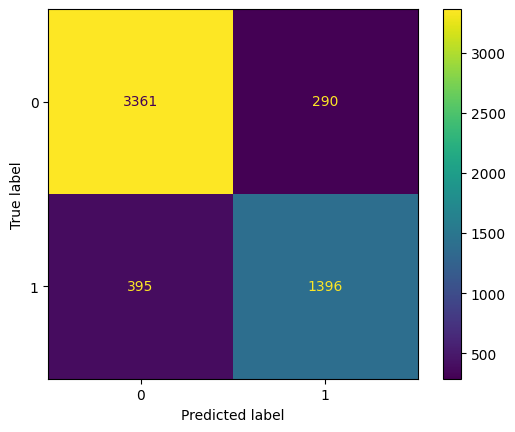

In [12]:
ConfusionMatrixDisplay.from_predictions(y_test, svc_model.predict(X_test_processed))

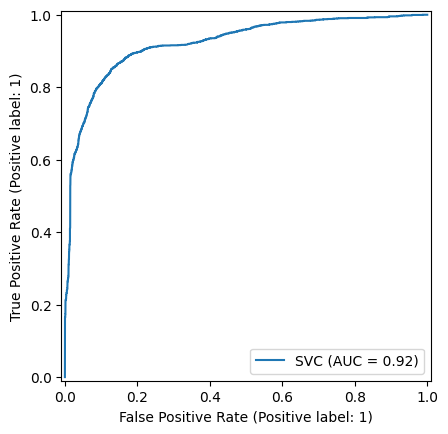

In [13]:
RocCurveDisplay.from_estimator(svc_model, X_test_processed, y_test)